# Review 1 — Regression: K-Nearest Neighbors Regressor




## 1. Dataset loading and audit

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
DATA_PATH = r"airfoil_with_missing.csv"
TARGET = "Scaled_Sound_Pressure_Level_dB"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1503, 6)


,Frequency_Hz,Angle_of_Attack_deg,Chord_Length_m,Free_Stream_Velocity_mps,Suction_Side_Displacement_Thickness_m,Scaled_Sound_Pressure_Level_dB
0,800.0,0.0,0.3048,71.3,0.002663,126.201
1,1000.0,0.0,0.3048,71.3,0.002663,125.201
2,1250.0,0.0,0.3048,71.3,0.002663,125.951
3,1600.0,0.0,0.3048,71.3,0.002663,127.591
4,2000.0,0.0,0.3048,71.3,0.002663,127.461


In [4]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget summary:")
display(df[TARGET].describe().to_frame("value"))


Data types:


,dtype
Frequency_Hz,float64
Angle_of_Attack_deg,float64
Chord_Length_m,float64
Free_Stream_Velocity_mps,float64
Suction_Side_Displacement_Thickness_m,float64
Scaled_Sound_Pressure_Level_dB,float64



Missing values:


,missing_count
Frequency_Hz,75
Angle_of_Attack_deg,75
Chord_Length_m,75
Free_Stream_Velocity_mps,75
Suction_Side_Displacement_Thickness_m,75
Scaled_Sound_Pressure_Level_dB,0



Duplicate rows: 0

Target summary:


,value
count,1503.000000
mean,124.835943
std,6.898657
min,103.380000
25%,120.191000
50%,125.721000
75%,129.995500
max,140.987000


## 2. Exploratory Data Analysis

Run the plots and replace the observation placeholders with your team's own findings.

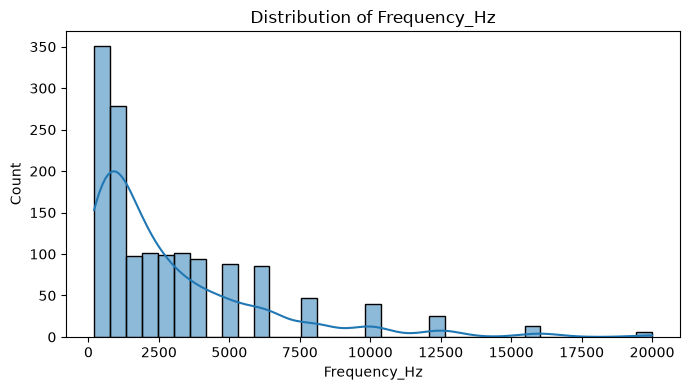

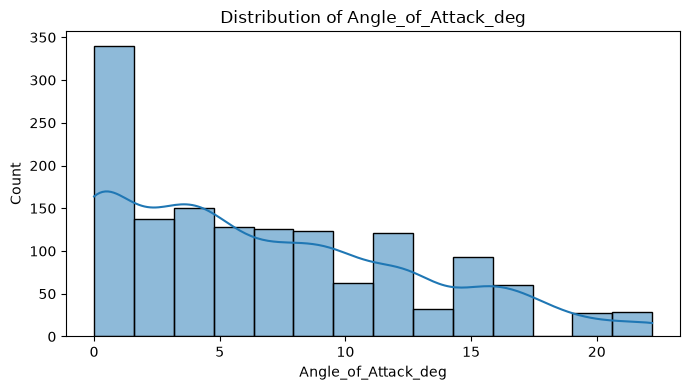

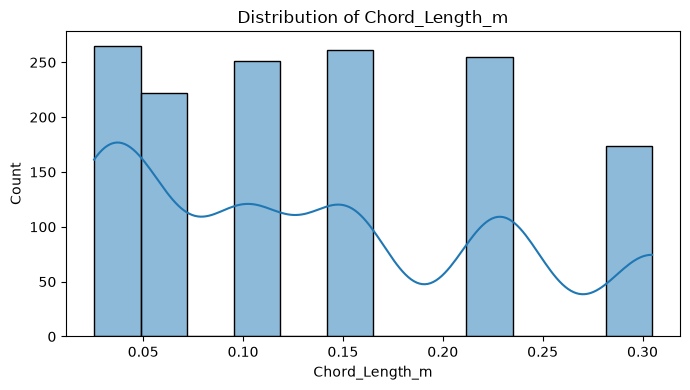

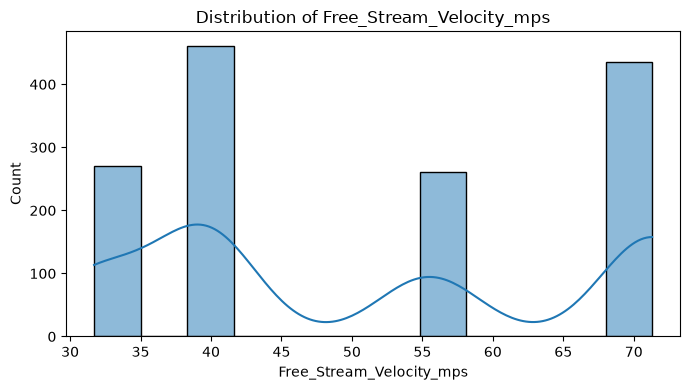

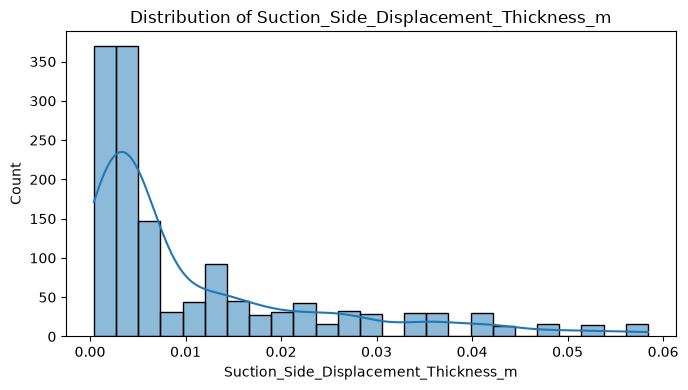

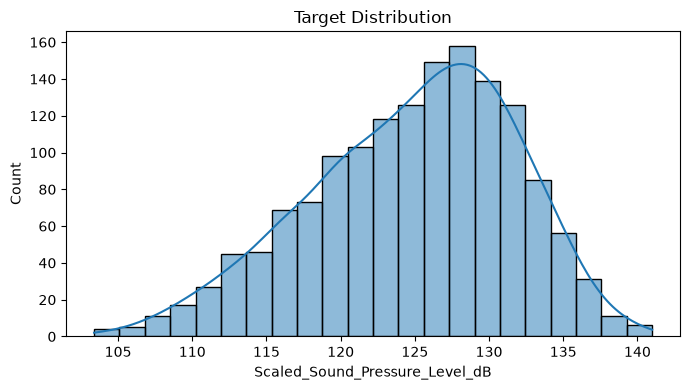

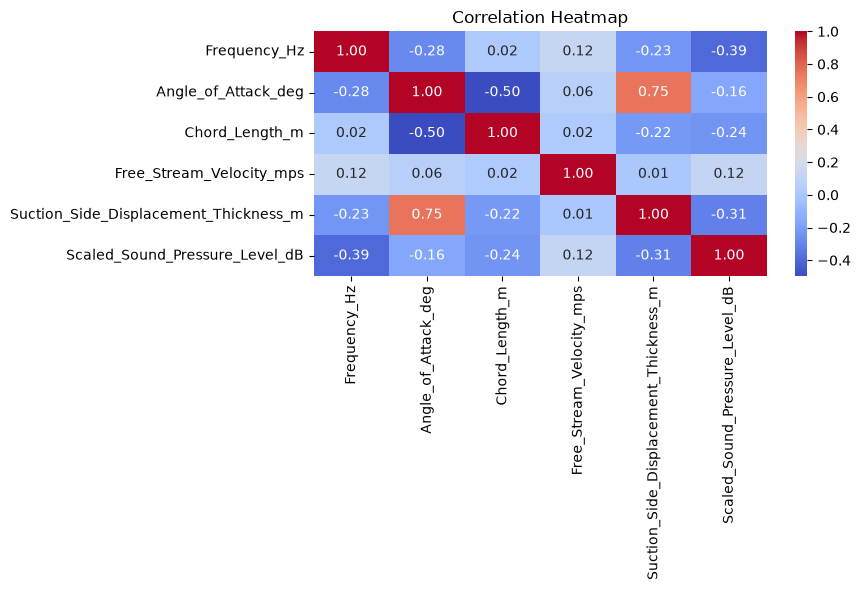

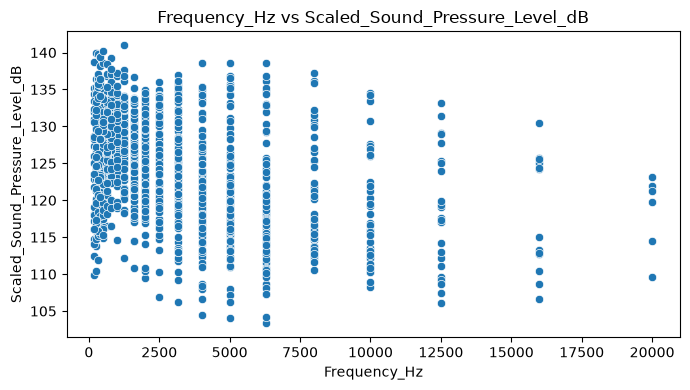

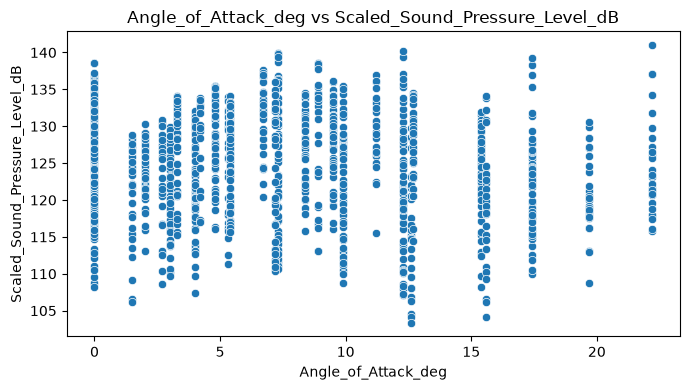

1. Distribution-plot observations:
For Frequency-distribution: the histogram is left skwed as the frequency of major samples are concentrated on the right.
For the feature Angle_of_Attack_deg,chord_length_m,Free_Stream_Velocity_mps the samples are distributed quite well and no visible skewness is seen
For the Suction_Side_Displacement_Thickness_m : The histogrma is left skewed as the samples are concentrated on the left end of the graph
2. Target-distribution observation: We get a bell shaped curve therefore no skewness.
3. Correlation-heatmap observation:This helps us to understand the linear relatonship between the target and numerical features.
The target has the strongest negative correlation with Frequency_Hz (-0.39), followed by Suction_Side_Displacement_Thickness_m (-0.31).
 Chord_Length_m also has a moderate negative correlation (-0.24), while Angle_of_Attack_deg has a weak negative correlation (-0.16).
 Free_Stream_Velocity_mps has a very weak positive correlation (0.12) with 

In [5]:
feature_cols = [c for c in df.columns if c != TARGET]

for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df[TARGET], kde=True)
plt.title("Target Distribution")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

for col in feature_cols[:2]:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df, x=col, y=TARGET)
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

print("1. Distribution-plot observations:")
print("For Frequency-distribution: the histogram is left skwed as the frequency of major samples are concentrated on the right.")
print("For the feature Angle_of_Attack_deg,chord_length_m,Free_Stream_Velocity_mps the samples are distributed quite well and no visible skewness is seen")
print("For the Suction_Side_Displacement_Thickness_m : The histogrma is left skewed as the samples are concentrated on the left end of the graph")
print("2. Target-distribution observation: We get a bell shaped curve therefore no skewness.")
print("3. Correlation-heatmap observation:This helps us to understand the linear relatonship between the target and numerical features.\nThe target has the strongest negative correlation with Frequency_Hz (-0.39), followed by Suction_Side_Displacement_Thickness_m (-0.31).\n Chord_Length_m also has a moderate negative correlation (-0.24), while Angle_of_Attack_deg has a weak negative correlation (-0.16).\n Free_Stream_Velocity_mps has a very weak positive correlation (0.12) with the target.")
print("4. Two feature-target scatter observations")
print("For the frequency vs target we can ssee a downward pattern in the plot which agrees with the negative correlation of -0.39, but the samples are mostly clearly scattered")
print("For Angle_of_Attack_deg vs target, the sample is scattered with no clear linear rise or fall pattern.")

## 3. Preprocessing and Feature Engineering

In [6]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# Feature engineering required for the project.
X["Velocity_AOA_Interaction"] = (
    X["Angle_of_Attack_deg"] * X["Free_Stream_Velocity_mps"]
)

# Same 80:20 split for every regression algorithm.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Fit imputation only on training data.
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# IQR outlier treatment: thresholds learned from training data only.
Q1 = X_train_imp.quantile(0.25)
Q3 = X_train_imp.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train_clip = X_train_imp.clip(lower=lower, upper=upper, axis="columns")
X_test_clip = X_test_imp.clip(lower=lower, upper=upper, axis="columns")

# Fit scaler only on training data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clip)
X_test_scaled = scaler.transform(X_test_clip)

print("Training samples:", len(X_train_scaled))
print("Test samples:", len(X_test_scaled))
print("Final feature count:", X_train_scaled.shape[1])
print("Features:", list(X.columns))


Training samples: 1202
Test samples: 301
Final feature count: 6
Features: ['Frequency_Hz', 'Angle_of_Attack_deg', 'Chord_Length_m', 'Free_Stream_Velocity_mps', 'Suction_Side_Displacement_Thickness_m', 'Velocity_AOA_Interaction']


## 4. Model Training and Evaluation

In [7]:
def show_results(y_true, pred):
    result = pd.DataFrame([{
        "R2": r2_score(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "MAE": mean_absolute_error(y_true, pred)
    }])
    display(result.style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    }))
    return result


In [8]:
from sklearn.neighbors import KNeighborsRegressor

MODEL_NAME = "K-Nearest Neighbors Regressor"
grid = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors": [3, 5, 7, 9, 11, 15],
     "weights": ["uniform", "distance"],
     "p": [1, 2]},
    cv=5, scoring="r2", n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

model = grid.best_estimator_
predictions = model.predict(X_test_scaled)
print("Best parameters:", grid.best_params_)
print("Best mean CV R2:", grid.best_score_)
show_results(y_test, predictions)

cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
print("Mean 5-fold CV R2:", cv.mean())


Best parameters: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Best mean CV R2: 0.7394103401508008


,R2,RMSE,MAE
0,0.6541,4.1630,3.0211


Mean 5-fold CV R2: 0.7394103401508008


## 5. Predicted vs Actual and Residual Plots

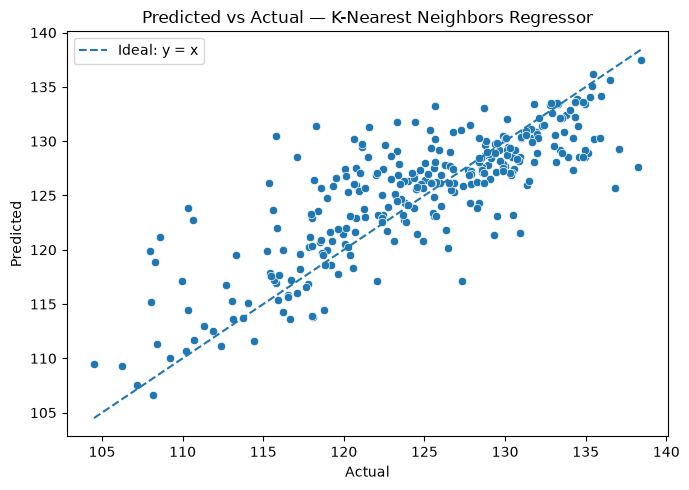

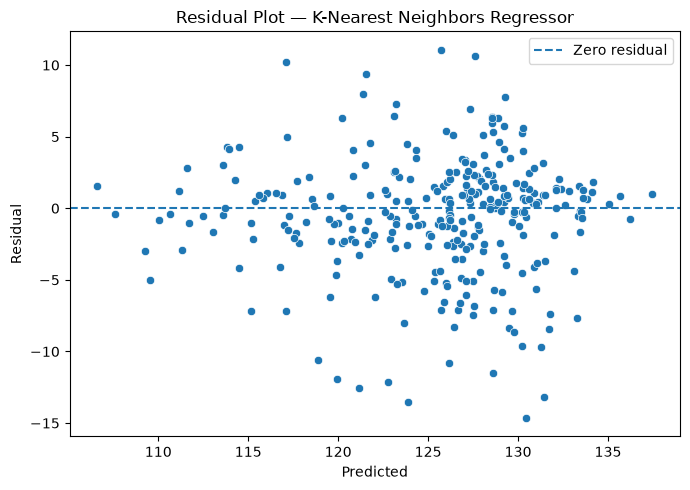

Observation:
The predicted values generally follow the actual values, showing a clear positive relationship between them. However, the points are more widely scattered around the ideal y=x line, especially in the middle range of actual values.
This indicates that the KNN Regressor captures the overall trend but has noticeable prediction errors for several observations.
Residuals:Most residuals are concentrated around zero, but several observations have relatively large residuals


In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=predictions)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, linestyle="--", label="Ideal: y = x")
plt.title(f"Predicted vs Actual — {MODEL_NAME}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - predictions
plt.figure(figsize=(7, 5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(0, linestyle="--", label="Zero residual")
plt.title(f"Residual Plot — {MODEL_NAME}")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

print("Observation:")
print("The predicted values generally follow the actual values, showing a clear positive relationship between them. However, the points are more widely scattered around the ideal y=x line, especially in the middle range of actual values.\nThis indicates that the KNN Regressor captures the overall trend but has noticeable prediction errors for several observations.")
print("Residuals:Most residuals are concentrated around zero, but several observations have relatively large residuals")